## Setup

In [1]:
import json
import re
import warnings
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import Markdown, display

warnings.filterwarnings("ignore")

%matplotlib inline
plt.rcParams["figure.figsize"] = (12, 6)
plt.rcParams["font.size"] = 11


def find_project_root(start: Path | None = None) -> Path:
    start = (start or Path.cwd()).resolve()
    for candidate in [start, *start.parents]:
        if (candidate / "data").exists() and (candidate / "notebooks").exists():
            return candidate
    raise FileNotFoundError("Could not locate the project root from the current working directory.")


def show_note(message: str, heading: str = "Key finding") -> None:
    display(Markdown(f"> **{heading}.** {message}"))


def flatten_list_column(series: pd.Series) -> pd.Series:
    values = [item for row in series if isinstance(row, list) for item in row]
    return pd.Series(values, dtype="object")


PROJECT_ROOT = find_project_root()
DATA_DIR = PROJECT_ROOT / "data"
MODULES_PATH = DATA_DIR / "modules.csv"
JOBS_DIR = DATA_DIR / "MyCareersFutureData"

print(f"Project root: {PROJECT_ROOT}")
print(f"Modules path: {MODULES_PATH}")
print(f"Jobs directory: {JOBS_DIR}")

Project root: /Users/marcusyeo/Github/DSA4264-Text-Group-3
Modules path: /Users/marcusyeo/Github/DSA4264-Text-Group-3/data/modules.csv
Jobs directory: /Users/marcusyeo/Github/DSA4264-Text-Group-3/data/MyCareersFutureData


## Load Datasets

In [2]:
if not MODULES_PATH.exists():
    raise FileNotFoundError(f"Modules file not found: {MODULES_PATH}")

modules_df = pd.read_csv(MODULES_PATH)

print(f"Loaded modules from: {MODULES_PATH}")
print(f"Dataset shape: {modules_df.shape}")
print(f"Columns: {list(modules_df.columns)}")
display(modules_df.head())

show_note(
    f"The module catalogue contains {len(modules_df):,} rows across "
    f"{modules_df['faculty'].nunique():,} faculties, so the rest of the notebook can profile one consolidated source of curriculum data."
)

Loaded modules from: /Users/marcusyeo/Github/DSA4264-Text-Group-3/data/modules.csv
Dataset shape: (7014, 14)
Columns: ['moduleCode', 'title', 'acadYear', 'faculty', 'department', 'moduleCredit', 'description', 'additionalInformation', 'workload', 'gradingBasisDescription', 'preclusion', 'prerequisite', 'corequisite', 'semestersOffered']


,moduleCode,title,acadYear,faculty,department,moduleCredit,description,additionalInformation,workload,gradingBasisDescription,preclusion,prerequisite,corequisite,semestersOffered
0,ABM5001,Leadership in Biomedicine,2024/2025,Yong Loo Lin Sch of Medicine,NUS Medicine Dean's Office,2.0,Leadership is fundamental to the success of in...,NaN,3/0/0/4/3,Graded,NaN,NaN,NaN,2
1,ABM5002,Advanced Biostatistics for Research,2024/2025,Yong Loo Lin Sch of Medicine,NUS Medicine Dean's Office,2.0,This course is served as a concept-based intro...,NaN,1.5/0.5/0/0/3,Graded,NaN,NaN,NaN,2
2,ABM5003,Biomedical Innovation & Enterprise,2024/2025,Yong Loo Lin Sch of Medicine,NUS Medicine Dean's Office,4.0,This course will furnish students with a thoro...,NaN,1.5/1.5/0/3/4,Graded,NaN,NaN,NaN,1
3,ABM5004,Capstone Project,2024/2025,Yong Loo Lin Sch of Medicine,NUS Medicine Dean's Office,8.0,This course encompasses research projects rele...,NaN,0/0/18/2/0,Graded,NaN,NaN,NaN,"1,2"
4,ABM5101,Applied Immunology,2024/2025,Yong Loo Lin Sch of Medicine,NUS Medicine Dean's Office,4.0,Advanced immunological applications play impor...,NaN,2/2.5/0/1/4.5,Graded,NaN,NaN,NaN,1


> **Key finding.** The module catalogue contains 7,014 rows across 24 faculties, so the rest of the notebook can profile one consolidated source of curriculum data.

### EDA: Module Catalogue

This section checks the structure of the module dataset, highlights where missingness is concentrated, and verifies whether module descriptions are detailed enough for downstream skill matching.

In [3]:
profile = pd.DataFrame(
    {
        "dtype": modules_df.dtypes.astype(str),
        "non_null_count": modules_df.notna().sum(),
        "missing_count": modules_df.isna().sum(),
        "missing_pct": (modules_df.isna().mean() * 100).round(2),
        "n_unique": modules_df.nunique(dropna=True),
    }
).sort_values(["missing_count", "n_unique"], ascending=[False, False])

display(profile)

sparse_columns = profile.loc[profile["missing_count"] > 0].head(3).index.tolist()
if sparse_columns:
    show_note(
        "Missingness is concentrated in a few optional text fields: "
        + ", ".join(f"`{column}`" for column in sparse_columns)
        + ". Core identifiers such as `moduleCode`, `title`, and `faculty` are complete."
    )
else:
    show_note("The module table is fully populated, including both identifiers and text fields.")

,dtype,non_null_count,missing_count,missing_pct,n_unique
additionalInformation,str,89,6925,98.73,61
corequisite,str,105,6909,98.50,81
prerequisite,str,2967,4047,57.70,2170
preclusion,str,3037,3977,56.70,2826
workload,str,6803,211,3.01,949
description,str,6867,147,2.10,5403
moduleCode,str,7014,0,0.00,7014
title,str,7014,0,0.00,5181
department,str,7014,0,0.00,92
moduleCredit,float64,7014,0,0.00,27


> **Key finding.** Missingness is concentrated in a few optional text fields: `additionalInformation`, `corequisite`, `prerequisite`. Core identifiers such as `moduleCode`, `title`, and `faculty` are complete.

#### Missingness And Structural Balance

,missing_count,missing_pct
additionalInformation,6925,98.73%
corequisite,6909,98.50%
prerequisite,4047,57.70%
preclusion,3977,56.70%
workload,211,3.01%
description,147,2.10%


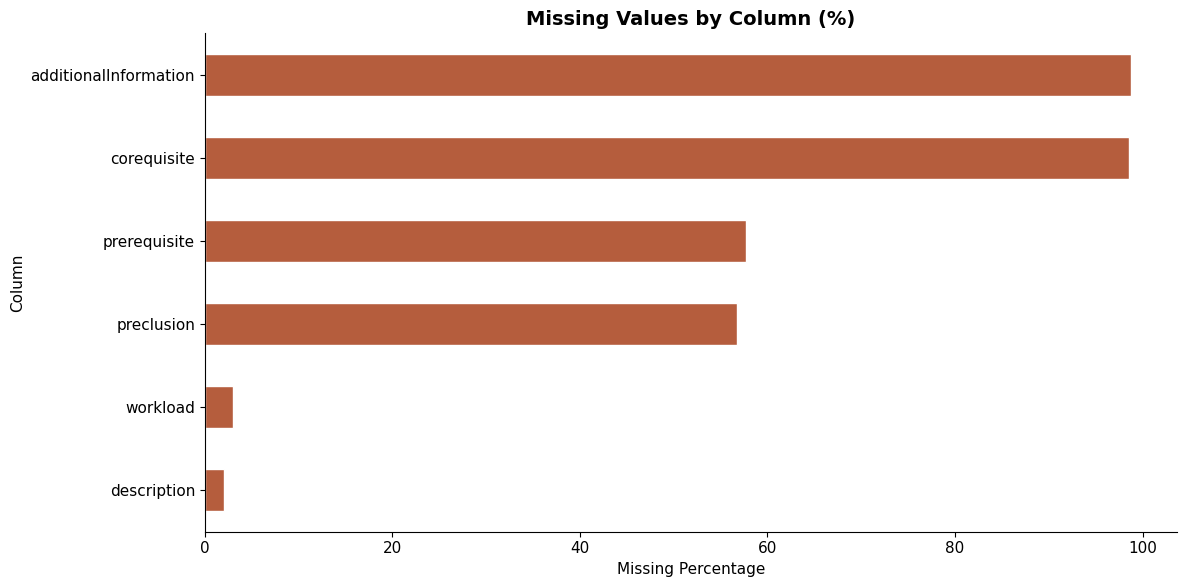

> **Key finding.** Most missingness sits in optional relationship fields such as prerequisites, preclusions, and additional notes. That means the catalogue is still reliable for descriptive text analysis even though some curriculum constraints are incomplete.

In [4]:
missing_summary = profile.loc[profile["missing_count"] > 0, ["missing_count", "missing_pct"]]

if missing_summary.empty:
    print("No missing values detected in modules_df.")
    show_note("There are no null-heavy columns to clean before downstream analysis.")
else:
    display(missing_summary.style.format({"missing_pct": "{:.2f}%"}))
    ax = missing_summary.sort_values("missing_pct").plot(
        kind="barh", y="missing_pct", legend=False, color="#b55d3d", edgecolor="white"
    )
    ax.set_title("Missing Values by Column (%)", fontsize=14, fontweight="bold")
    ax.set_xlabel("Missing Percentage")
    ax.set_ylabel("Column")
    ax.spines[["top", "right"]].set_visible(False)
    plt.tight_layout()
    plt.show()

    show_note(
        "Most missingness sits in optional relationship fields such as prerequisites, preclusions, and additional notes. "
        "That means the catalogue is still reliable for descriptive text analysis even though some curriculum constraints are incomplete."
    )

#### Duplicate Checks On Useful Keys

In [5]:
exact_duplicates = modules_df.duplicated().sum()
print(f"Exact duplicate rows: {exact_duplicates}")

key_candidates = [c for c in modules_df.columns if any(token in c.lower() for token in ["code", "id", "title", "name"])]
duplicate_checks = []

for col in key_candidates:
    duplicate_checks.append(
        {
            "column": col,
            "duplicated_values": int(modules_df[col].duplicated().sum()),
            "unique_values": int(modules_df[col].nunique(dropna=True)),
        }
    )

if duplicate_checks:
    duplicate_checks_df = pd.DataFrame(duplicate_checks).sort_values("duplicated_values", ascending=False)
    display(duplicate_checks_df)
else:
    duplicate_checks_df = pd.DataFrame(columns=["column", "duplicated_values", "unique_values"])
    print("No obvious code/id/title columns detected for duplicate-key checks.")

module_code_dup = int(modules_df["moduleCode"].duplicated().sum()) if "moduleCode" in modules_df.columns else None
title_dup = int(modules_df["title"].duplicated().sum()) if "title" in modules_df.columns else None

if module_code_dup == 0:
    show_note(
        f"`moduleCode` is unique across all {len(modules_df):,} rows, so the dataset already behaves like one row per module. "
        f"Repeated titles ({title_dup:,} duplicates) are expected because multiple modules can share generic naming patterns."
    )
else:
    show_note("There are duplicate module codes, so the catalogue should be deduplicated before it is used as a lookup table.")

Exact duplicate rows: 0


,column,duplicated_values,unique_values
1,title,1833,5181
0,moduleCode,0,7014


> **Key finding.** `moduleCode` is unique across all 7,014 rows, so the dataset already behaves like one row per module. Repeated titles (1,833 duplicates) are expected because multiple modules can share generic naming patterns.

#### Category Balance

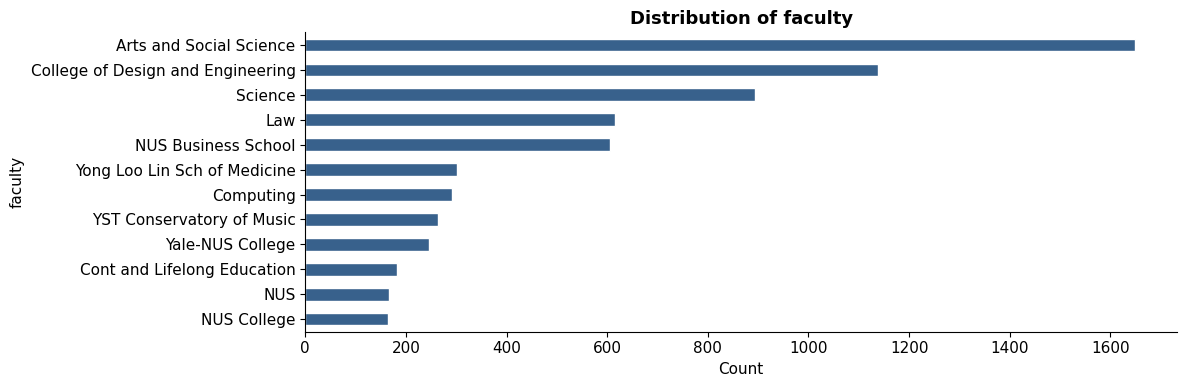

> **Key finding.** The catalogue is not evenly distributed by faculty: `Arts and Social Science` alone contributes about 23.5% of all rows. That imbalance is useful context when interpreting any aggregate module-text statistics.

In [6]:
plot_columns = [c for c in ["faculty"] if c in modules_df.columns]

if not plot_columns:
    print("No low-cardinality categorical columns found to visualize.")
    show_note("The dataset has no compact categorical columns that are suitable for a simple balance check.")
else:
    fig, axes = plt.subplots(len(plot_columns), 1, figsize=(12, 4 * len(plot_columns)))
    if len(plot_columns) == 1:
        axes = [axes]

    palette = ["#38618c", "#4e7a32", "#9a6228", "#7d4e91"]
    for ax, col, color in zip(axes, plot_columns, palette):
        counts = modules_df[col].fillna("Missing").value_counts().head(12).sort_values()
        counts.plot(kind="barh", ax=ax, color=color, edgecolor="white")
        ax.set_title(f"Distribution of {col}", fontsize=13, fontweight="bold")
        ax.set_xlabel("Count")
        ax.spines[["top", "right"]].set_visible(False)
    plt.tight_layout()
    plt.show()

    top_faculty = modules_df["faculty"].fillna("Missing").value_counts().idxmax()
    top_share = modules_df["faculty"].fillna("Missing").value_counts(normalize=True).iloc[0] * 100
    show_note(
        f"The catalogue is not evenly distributed by faculty: `{top_faculty}` alone contributes about {top_share:.1f}% of all rows. "
        "That imbalance is useful context when interpreting any aggregate module-text statistics."
    )

#### Description Quality And Noise

Using text column for EDA: description


,metric,count
0,Modules with missing descriptions,285
1,Missing-description modules inferred as semina...,93
2,Missing-description modules kept and filled wi...,192


,moduleCode,title,faculty,inferred_type
3956,LSM3288,Advanced UROPS in Life Sciences I,Science,seminar_or_project_like
3958,LSM3289,Advanced UROPS in Life Sciences II,Science,seminar_or_project_like
1242,CP4101,B.Comp. Dissertation,Computing,seminar_or_project_like
1069,CM2289,Basic UROPS In Chemistry II,Science,seminar_or_project_like
1067,CM2288,Basic UROPS in Chemistry I,Science,seminar_or_project_like
3907,LSM2288,Basic UROPS in Life Sciences I,Science,seminar_or_project_like
3909,LSM2289,Basic UROPS in Life Sciences II,Science,seminar_or_project_like
1427,DBA5102,Business Analytics Capstone Project,NUS Business School,seminar_or_project_like
623,BPS5000,Dissertation,College of Design and Engineering,seminar_or_project_like
619,BN6999,Doctoral Seminars,College of Design and Engineering,seminar_or_project_like


,count,mean,std,min,25%,50%,75%,max
char_count,6921.0,560.109522,219.625906,8.0,436.0,595.0,682.0,2120.0
word_count,6921.0,80.255743,31.601487,1.0,62.0,87.0,98.0,300.0


Rows removed from description analysis: 93
Rows using title as fallback description: 192


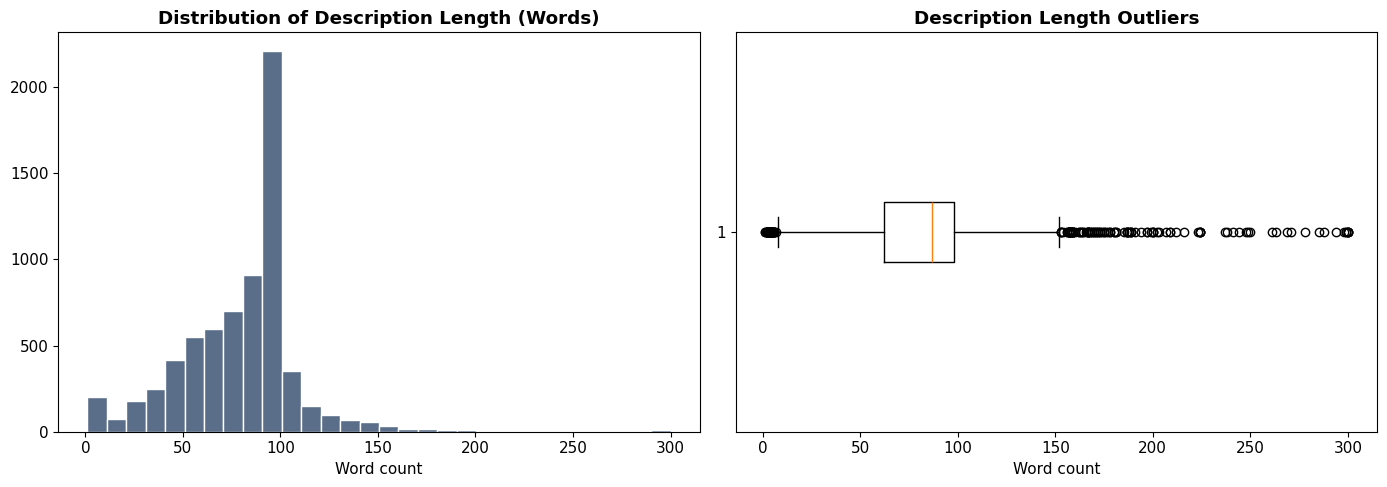

,moduleCode,title,description_for_eda
287,BMA5112A,Topics in Asian Business Environment,Topics in Asian Business Environment
299,BMA5302A,Investment Analysis & Management,Investment Analysis & Management
302,BMA5313A,Valuation and Mergers & Acquisitions,Valuation and Mergers & Acquisitions
323,BMA5524,Marketing Analytics,Marketing Analytics
324,BMA5528,Business to Business Marketing,Business to Business Marketing
699,BZD6011,Advanced Quantitative Research Methods,Advanced Quantitative Research Methods
815,CE5203,Traffic Flow & Control,Traffic Flow & Control
1286,CS2309,CS Research Methodology,CS Research Methodology
1440,DEP5101,Urban Analysis Workshop,Urban Analysis Workshop
1445,DEP5105,Urban Infrastructure and Mobility Systems,Urban Infrastructure and Mobility Systems


,moduleCode,title,faculty,description
0,ABM5001,Leadership in Biomedicine,Yong Loo Lin Sch of Medicine,Leadership is fundamental to the success of in...
1,ABM5002,Advanced Biostatistics for Research,Yong Loo Lin Sch of Medicine,This course is served as a concept-based intro...
2,ABM5003,Biomedical Innovation & Enterprise,Yong Loo Lin Sch of Medicine,This course will furnish students with a thoro...
3,ABM5004,Capstone Project,Yong Loo Lin Sch of Medicine,This course encompasses research projects rele...
4,ABM5101,Applied Immunology,Yong Loo Lin Sch of Medicine,Advanced immunological applications play impor...
5,ABM5102,Vaccine development and its modern applications,Yong Loo Lin Sch of Medicine,Use of vaccines and successful immunization ha...
6,ABM5103,Advanced technologies in immune therapeutic de...,Yong Loo Lin Sch of Medicine,The advancement of technologies for immune sys...
7,ABM5104,Microbiome-Aging-Immunity crosstalk,Yong Loo Lin Sch of Medicine,The complex relationship between human microbi...
8,ABM5105,Drugs used in Infectious Diseases,Yong Loo Lin Sch of Medicine,This course imparts students on the knowledge ...
9,ABM5106,Anticancer Therapeutics,Yong Loo Lin Sch of Medicine,This course will introduce different classes o...


> **Key finding.** Only 285 modules have blank descriptions. After removing project-like placeholders and using the title as a fallback where reasonable, the cleaned text still has a median length of 87 words, which is usually rich enough for downstream semantic matching.

In [7]:
description_col = "description"
title_col = "title"
module_code_col = "moduleCode"
print(f"Using text column for EDA: {description_col}")

modules_eda = modules_df[[module_code_col, title_col, "faculty", description_col]].copy()
raw_desc = modules_eda[description_col].fillna("").astype(str).str.strip()
invalid_desc_values = {"", "nan", "none", "not available", "n/a"}
blank_desc_mask = raw_desc.str.lower().isin(invalid_desc_values)

seminar_project_keywords = [
    "seminar",
    "project",
    "thesis",
    "dissertation",
    "capstone",
    "internship",
    "attachment",
    "practicum",
    "independent study",
    "independent work",
    "urops",
    "research opportunities programme",
    "honours thesis",
    "honors thesis",
]
title_pattern = "|".join(re.escape(keyword) for keyword in seminar_project_keywords)
seminar_project_mask = modules_eda[title_col].fillna("").str.lower().str.contains(title_pattern, regex=True)

missing_desc_modules = modules_eda.loc[blank_desc_mask].copy()
missing_desc_modules["inferred_type"] = np.where(
    seminar_project_mask.loc[blank_desc_mask],
    "seminar_or_project_like",
    "use_title_as_fallback",
)

display(
    pd.DataFrame(
        {
            "metric": [
                "Modules with missing descriptions",
                "Missing-description modules inferred as seminar/project-like",
                "Missing-description modules kept and filled with title",
            ],
            "count": [
                int(blank_desc_mask.sum()),
                int((blank_desc_mask & seminar_project_mask).sum()),
                int((blank_desc_mask & ~seminar_project_mask).sum()),
            ],
        }
    )
)

display(
    missing_desc_modules[[module_code_col, title_col, "faculty", "inferred_type"]]
    .sort_values(["inferred_type", title_col])
    .head(20)
)

modules_eda["description_for_eda"] = raw_desc
modules_eda.loc[blank_desc_mask & ~seminar_project_mask, "description_for_eda"] = modules_eda.loc[
    blank_desc_mask & ~seminar_project_mask, title_col
]

analysis_mask = ~(blank_desc_mask & seminar_project_mask)
analysis_modules = modules_eda.loc[analysis_mask].copy()
text_series = analysis_modules["description_for_eda"]

desc_stats = pd.DataFrame(
    {
        "char_count": text_series.str.len(),
        "word_count": text_series.str.split().str.len(),
        "used_title_as_fallback": analysis_modules["description_for_eda"].eq(analysis_modules[title_col]),
    }
)
display(desc_stats.describe().T)
print(f"Rows removed from description analysis: {(blank_desc_mask & seminar_project_mask).sum()}")
print(f"Rows using title as fallback description: {(blank_desc_mask & ~seminar_project_mask).sum()}")

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].hist(desc_stats["word_count"], bins=30, color="#5a6e8a", edgecolor="white")
axes[0].set_title("Distribution of Description Length (Words)", fontweight="bold")
axes[0].set_xlabel("Word count")
axes[1].boxplot(desc_stats["word_count"], vert=False)
axes[1].set_title("Description Length Outliers", fontweight="bold")
axes[1].set_xlabel("Word count")
plt.tight_layout()
plt.show()

short_examples = analysis_modules.loc[
    desc_stats["word_count"] <= 5,
    [module_code_col, title_col, "description_for_eda"],
].head(10)
display(short_examples)

cleaned_modules_df = analysis_modules[[module_code_col, title_col, "faculty", "description_for_eda"]].rename(
    columns={"description_for_eda": "description"}
)
display(cleaned_modules_df.head(20))

show_note(
    f"Only {blank_desc_mask.sum():,} modules have blank descriptions. After removing project-like placeholders and using the title as a fallback where reasonable, "
    f"the cleaned text still has a median length of {desc_stats['word_count'].median():.0f} words, which is usually rich enough for downstream semantic matching."
)

#### Module Composition Visuals

These visuals summarise where most modules come from and how much description cleaning was needed before analysis.

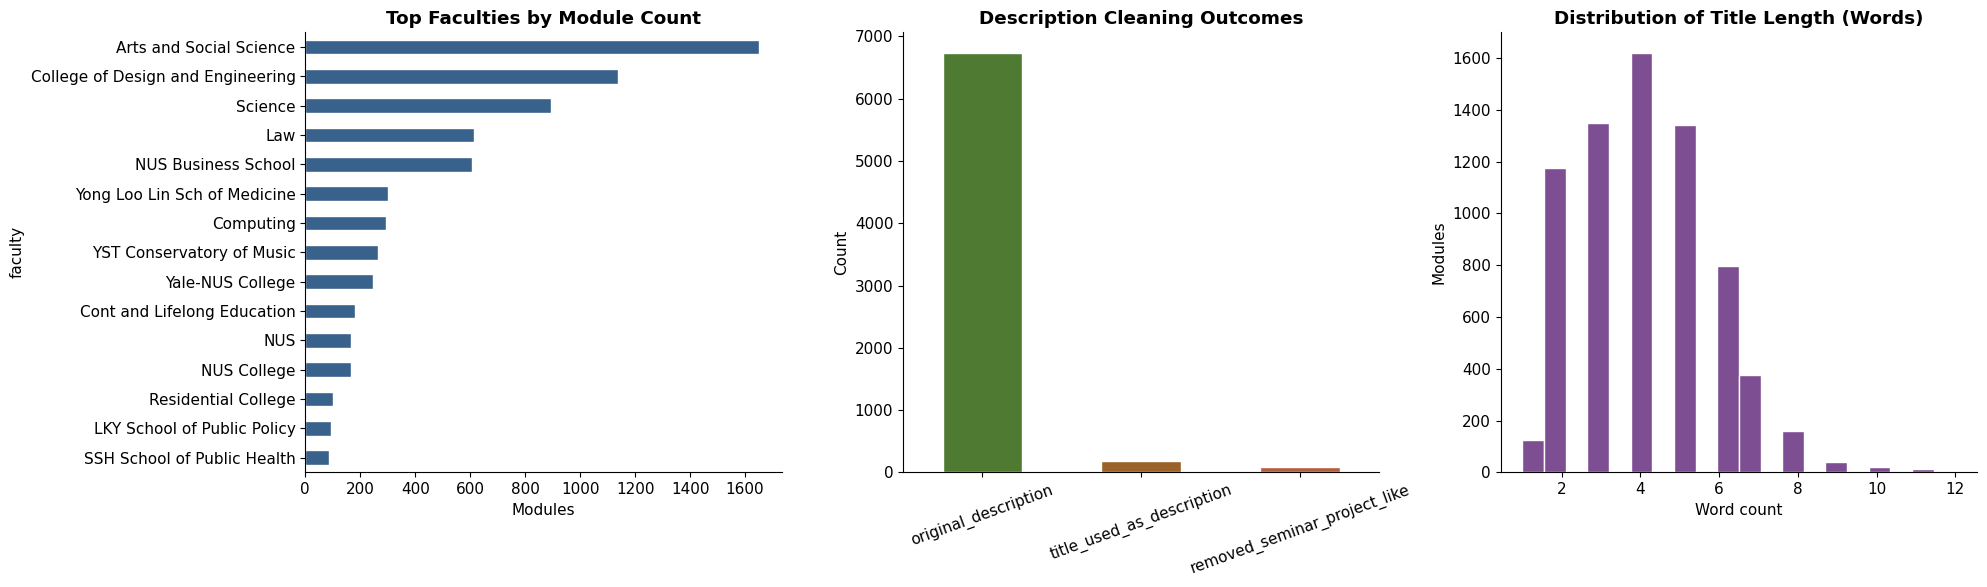

> **Key finding.** Most rows already carry a proper module description, and only a small minority needed fallback handling. The short-title distribution also helps explain why titles alone are a weak substitute for full descriptions.

In [8]:
faculty_counts = modules_df["faculty"].fillna("Missing").value_counts().head(15).sort_values()
fallback_counts = pd.Series(
    {
        "original_description": int((~blank_desc_mask).sum()),
        "title_used_as_description": int((blank_desc_mask & ~seminar_project_mask).sum()),
        "removed_seminar_project_like": int((blank_desc_mask & seminar_project_mask).sum()),
    }
)
title_word_counts = modules_df["title"].fillna("").astype(str).str.split().str.len()

fig, axes = plt.subplots(1, 3, figsize=(20, 6))
faculty_counts.plot(kind="barh", ax=axes[0], color="#38618c", edgecolor="white")
axes[0].set_title("Top Faculties by Module Count", fontweight="bold")
axes[0].set_xlabel("Modules")

fallback_counts.plot(kind="bar", ax=axes[1], color=["#4e7a32", "#9a6228", "#b55d3d"], edgecolor="white")
axes[1].set_title("Description Cleaning Outcomes", fontweight="bold")
axes[1].set_ylabel("Count")
axes[1].tick_params(axis="x", rotation=20)

axes[2].hist(title_word_counts, bins=20, color="#7d4e91", edgecolor="white")
axes[2].set_title("Distribution of Title Length (Words)", fontweight="bold")
axes[2].set_xlabel("Word count")
axes[2].set_ylabel("Modules")

for ax in axes:
    ax.spines[["top", "right"]].set_visible(False)
plt.tight_layout()
plt.show()

show_note(
    "Most rows already carry a proper module description, and only a small minority needed fallback handling. "
    "The short-title distribution also helps explain why titles alone are a weak substitute for full descriptions."
)

### EDA: Job Ads Dataset

This section loads the MyCareersFuture JSON files from the repository, flattens the tagged fields used for matching, and checks how concentrated the job market snapshot is.

In [9]:
if not JOBS_DIR.exists():
    raise FileNotFoundError(f"Jobs directory not found: {JOBS_DIR}")

job_files = sorted(JOBS_DIR.glob("*.json"))
print(f"Reading job ads from: {JOBS_DIR}")
print(f"JSON files detected: {len(job_files):,}")

show_note(
    "The job-ads analysis now uses the repository's `data/MyCareersFutureData` folder directly, which avoids mixing in unrelated JSON files from other data or cache directories."
)

Reading job ads from: /Users/marcusyeo/Github/DSA4264-Text-Group-3/data/MyCareersFutureData
JSON files detected: 22,720


> **Key finding.** The job-ads analysis now uses the repository's `data/MyCareersFutureData` folder directly, which avoids mixing in unrelated JSON files from other data or cache directories.

In [10]:
def load_jobs(folder: Path) -> list[dict]:
    folder = Path(folder)
    if not folder.exists():
        raise FileNotFoundError(f"Folder not found: {folder}")

    job_files = sorted(folder.glob("*.json"))
    jobs = []
    skipped_files = []

    for filepath in job_files:
        try:
            with open(filepath, "r", encoding="utf-8") as f:
                content = json.load(f)
            if isinstance(content, list):
                jobs.extend(item for item in content if isinstance(item, dict))
            elif isinstance(content, dict):
                jobs.append(content)
            else:
                skipped_files.append(f"{filepath.name} (unexpected JSON structure)")
        except Exception as exc:
            skipped_files.append(f"{filepath.name} ({exc})")

    if not jobs:
        raise ValueError(f"No readable job ad files found in {folder}")

    print(f"Total files scanned: {len(job_files):,}")
    print(f"Total job ads combined: {len(jobs):,}")
    if skipped_files:
        print("Skipped files:")
        for name in skipped_files[:10]:
            print(f"  - {name}")
        if len(skipped_files) > 10:
            print(f"  ... and {len(skipped_files) - 10} more")
    return jobs


def extract_fields(jobs: list[dict]) -> pd.DataFrame:
    rows = []
    for job in jobs:
        categories = [
            c.get("category", "").strip()
            for c in job.get("categories", [])
            if isinstance(c, dict) and c.get("category")
        ]
        skills = [
            s.get("skill", "").strip().lower()
            for s in job.get("skills", [])
            if isinstance(s, dict) and s.get("skill")
        ]
        employment_types = [
            e.get("employmentType", "").strip()
            for e in job.get("employmentTypes", [])
            if isinstance(e, dict) and e.get("employmentType")
        ]
        position_levels = [
            p.get("position", "").strip()
            for p in job.get("positionLevels", [])
            if isinstance(p, dict) and p.get("position")
        ]
        rows.append(
            {
                "job_id": job.get("metadata", {}).get("jobPostId", "N/A")
                if isinstance(job.get("metadata", {}), dict)
                else "N/A",
                "title": str(job.get("title", "Unknown")).strip() or "Unknown",
                "company": (
                    job.get("postedCompany", {}).get("name", "Unknown")
                    if isinstance(job.get("postedCompany", {}), dict)
                    else "Unknown"
                ),
                "categories": categories,
                "skills": skills,
                "employment_type": employment_types,
                "position_level": position_levels,
            }
        )
    return pd.DataFrame(rows)


jobs = load_jobs(JOBS_DIR)
df = extract_fields(jobs)
display(df.head())

show_note(
    f"The loader combines {len(df):,} postings into one flat table while preserving multi-label fields such as categories, skills, and employment types for later aggregation."
)

Total files scanned: 22,720
Total job ads combined: 22,720


,job_id,title,company,categories,skills,employment_type,position_level
0,ATS-2026-0184172,"Assistant Manager, Corporate Communications",CITY DEVELOPMENTS LIMITED,[Marketing / Public Relations],"[multimedia, social media, strategic communica...",[Permanent],[Junior Executive]
1,ATS-2026-0190206,Manager (Facilities Management),NTUC FAIRPRICE CO-OPERATIVE LTD,[Real Estate / Property Management],"[fire safety, management skills, sustainabilit...",[Permanent],[Manager]
2,MCF-2025-1100407,Sales Administrator,THE FULLERTON HOTEL,"[Hospitality, Sales / Retail]","[sales, microsoft office, microsoft excel, tra...",[Full Time],[Executive]
3,MCF-2025-1103608,Assistant Field Engineer(Construction),"ENZAN KOUBOU CO., LTD. Singapore Branch","[Customer Service, Engineering, Professional S...","[troubleshooting, construction, hardware, elec...",[Full Time],[Fresh/entry level]
4,MCF-2025-1105270,Electronic Keyboard Teacher,SYMPHONY MUSIC SCHOOL,[Education and Training],"[piano, classical, microsoft excel, teaching, ...",[Full Time],[Non-executive]


> **Key finding.** The loader combines 22,720 postings into one flat table while preserving multi-label fields such as categories, skills, and employment types for later aggregation.

In [11]:
df["category_count"] = df["categories"].apply(len)
df["skill_count"] = df["skills"].apply(len)
df["employment_type_count"] = df["employment_type"].apply(len)

all_categories = flatten_list_column(df["categories"])
all_skills = flatten_list_column(df["skills"])

summary = pd.DataFrame(
    {
        "Metric": [
            "Total job postings",
            "Unique job titles",
            "Unique companies",
            "Unique categories",
            "Total skill tags",
            "Unique skills",
            "Median skills per job",
            "Jobs without tagged skills",
        ],
        "Value": [
            len(df),
            df["title"].nunique(),
            df["company"].nunique(),
            all_categories.nunique(),
            int(df["skill_count"].sum()),
            all_skills.nunique(),
            float(df["skill_count"].median()),
            int((df["skill_count"] == 0).sum()),
        ],
    }
)
display(summary)

show_note(
    f"The market snapshot is broad: {df['title'].nunique():,} distinct titles and {all_skills.nunique():,} unique tagged skills appear across {len(df):,} postings. "
    f"The median job already lists {df['skill_count'].median():.0f} skills, so the job side is information-rich for alignment work."
)

,Metric,Value
0,Total job postings,22720.0
1,Unique job titles,14987.0
2,Unique companies,5377.0
3,Unique categories,43.0
4,Total skill tags,334729.0
5,Unique skills,9491.0
6,Median skills per job,15.0
7,Jobs without tagged skills,0.0


> **Key finding.** The market snapshot is broad: 14,987 distinct titles and 9,491 unique tagged skills appear across 22,720 postings. The median job already lists 15 skills, so the job side is information-rich for alignment work.

In [12]:
duplicate_check_df = df.copy()
duplicate_check_df["categories_key"] = duplicate_check_df["categories"].apply(
    lambda values: tuple(sorted(values)) if isinstance(values, list) else tuple()
)
duplicate_check_df["skills_key"] = duplicate_check_df["skills"].apply(
    lambda values: tuple(sorted(values)) if isinstance(values, list) else tuple()
)

duplicate_groups = (
    duplicate_check_df.groupby(["title", "company", "categories_key", "skills_key"], dropna=False)
    .agg(
        job_count=("job_id", "size"),
        unique_job_ids=("job_id", lambda values: sorted(set(values))),
        unique_position_levels=(
            "position_level",
            lambda values: sorted({tuple(v) if isinstance(v, list) else v for v in values}),
        ),
        unique_employment_types=(
            "employment_type",
            lambda values: sorted({tuple(v) if isinstance(v, list) else v for v in values}),
        ),
    )
    .reset_index()
)
duplicate_groups = duplicate_groups[duplicate_groups["job_count"] > 1].sort_values("job_count", ascending=False)

duplicate_summary = pd.DataFrame(
    {
        "metric": [
            "Potential duplicate job groups (ignoring job_id, position_level, employment_type)",
            "Total job rows involved in these duplicate groups",
        ],
        "count": [
            int(len(duplicate_groups)),
            int(duplicate_groups["job_count"].sum()) if not duplicate_groups.empty else 0,
        ],
    }
)
display(duplicate_summary)

if duplicate_groups.empty:
    print("No potential duplicate job ads found under this comparison rule.")
    show_note("The postings appear distinct under the current title-company-category-skill signature.")
else:
    duplicate_display = duplicate_groups.copy()
    duplicate_display["categories"] = duplicate_display["categories_key"].apply(list)
    duplicate_display["skills"] = duplicate_display["skills_key"].apply(list)
    display(
        duplicate_display[
            [
                "title",
                "company",
                "job_count",
                "unique_job_ids",
                "unique_position_levels",
                "unique_employment_types",
                "categories",
                "skills",
            ]
        ].head(20)
    )
    show_note(
        f"There are {len(duplicate_groups):,} repeated job signatures involving {duplicate_groups['job_count'].sum():,} rows. "
        "That suggests reposting or agency duplication is common enough to matter when evaluating job-market demand."
    )

,metric,count
0,Potential duplicate job groups (ignoring job_i...,1435
1,Total job rows involved in these duplicate groups,5044


,title,company,job_count,unique_job_ids,unique_position_levels,unique_employment_types,categories,skills
16999,Supervisor,DING FENG INFORMATION SERVICES PTE. LTD.,107,"[MCF-2026-0163616, MCF-2026-0163628, MCF-2026-...","[(Professional,), (Senior Executive,)]","[(Contract,)]",[General Work],"[ability to learn, coaching, compliance, const..."
10243,Marketing and Sales Trainee (Entry Level),ROYAL ORG PTE. LTD.,47,"[MCF-2026-0152901, MCF-2026-0152906, MCF-2026-...","[(Fresh/entry level,)]","[(Full Time,)]","[Marketing / Public Relations, Sales / Retail]","[ability to travel, coaching, communication sk..."
8759,Junior Sales and Marketing Representative,ROYAL ORG PTE. LTD.,35,"[MCF-2026-0152879, MCF-2026-0152883, MCF-2026-...","[(Fresh/entry level,)]","[(Full Time,)]","[Marketing / Public Relations, Sales / Retail]","[ability to travel, coaching, communication sk..."
6199,Event and Marketing (Entry Level),MYTHIC VISION,23,"[MCF-2026-0164033, MCF-2026-0164051, MCF-2026-...","[(Fresh/entry level,)]","[(Full Time,)]",[Marketing / Public Relations],"[communication skills, customer acquisition, c..."
10204,Marketing Trainee (No experience required),J&N VENTURES,22,"[MCF-2026-0154472, MCF-2026-0154476, MCF-2026-...","[(Fresh/entry level,)]","[(Full Time,)]","[Events / Promotions, Marketing / Public Relat...","[brand communication, coaching, communication,..."
14180,SUPERVISOR,OCEANDA HR PTE. LTD.,22,"[MCF-2026-0160999, MCF-2026-0161044, MCF-2026-...","[(Professional,)]","[(Contract, Full Time)]",[General Work],"[ability to learn, coaching, compliance, const..."
6885,Financial Consultant,LIONBROKERS PTE. LTD.,19,"[MCF-2026-0159375, MCF-2026-0159396, MCF-2026-...","[(Fresh/entry level,)]","[(Full Time,)]","[Insurance, Sales / Retail]","[banking, coaching, corporate finance, entrepr..."
14314,Sales & Marketing (No experience required),J&N VENTURES,14,"[MCF-2026-0159511, MCF-2026-0159548, MCF-2026-...","[(Fresh/entry level,)]","[(Full Time,)]","[Events / Promotions, Marketing / Public Relat...","[b2c communication, brand communication, coach..."
10039,Marketing Brand Ambassador (Fun environment 🥳),ROYAL ORG PTE. LTD.,14,"[MCF-2025-1953784, MCF-2025-1970673, MCF-2025-...","[(Junior Executive,)]","[(Permanent, Full Time)]","[Education and Training, Events / Promotions, ...","[able to work independently, brand awareness, ..."
773,ASSISTANT COOK,OCEANDA HR PTE. LTD.,13,"[MCF-2026-0160987, MCF-2026-0161026, MCF-2026-...","[(Professional,)]","[(Contract, Full Time)]",[F&B],"[able to multitask, assembling, childcare, coo..."


> **Key finding.** There are 1,435 repeated job signatures involving 5,044 rows. That suggests reposting or agency duplication is common enough to matter when evaluating job-market demand.

#### Job Ads Visual Deep Dive

These plots show where demand is concentrated, how dense the skill tagging is per posting, and how large the repeated-job clusters can become.

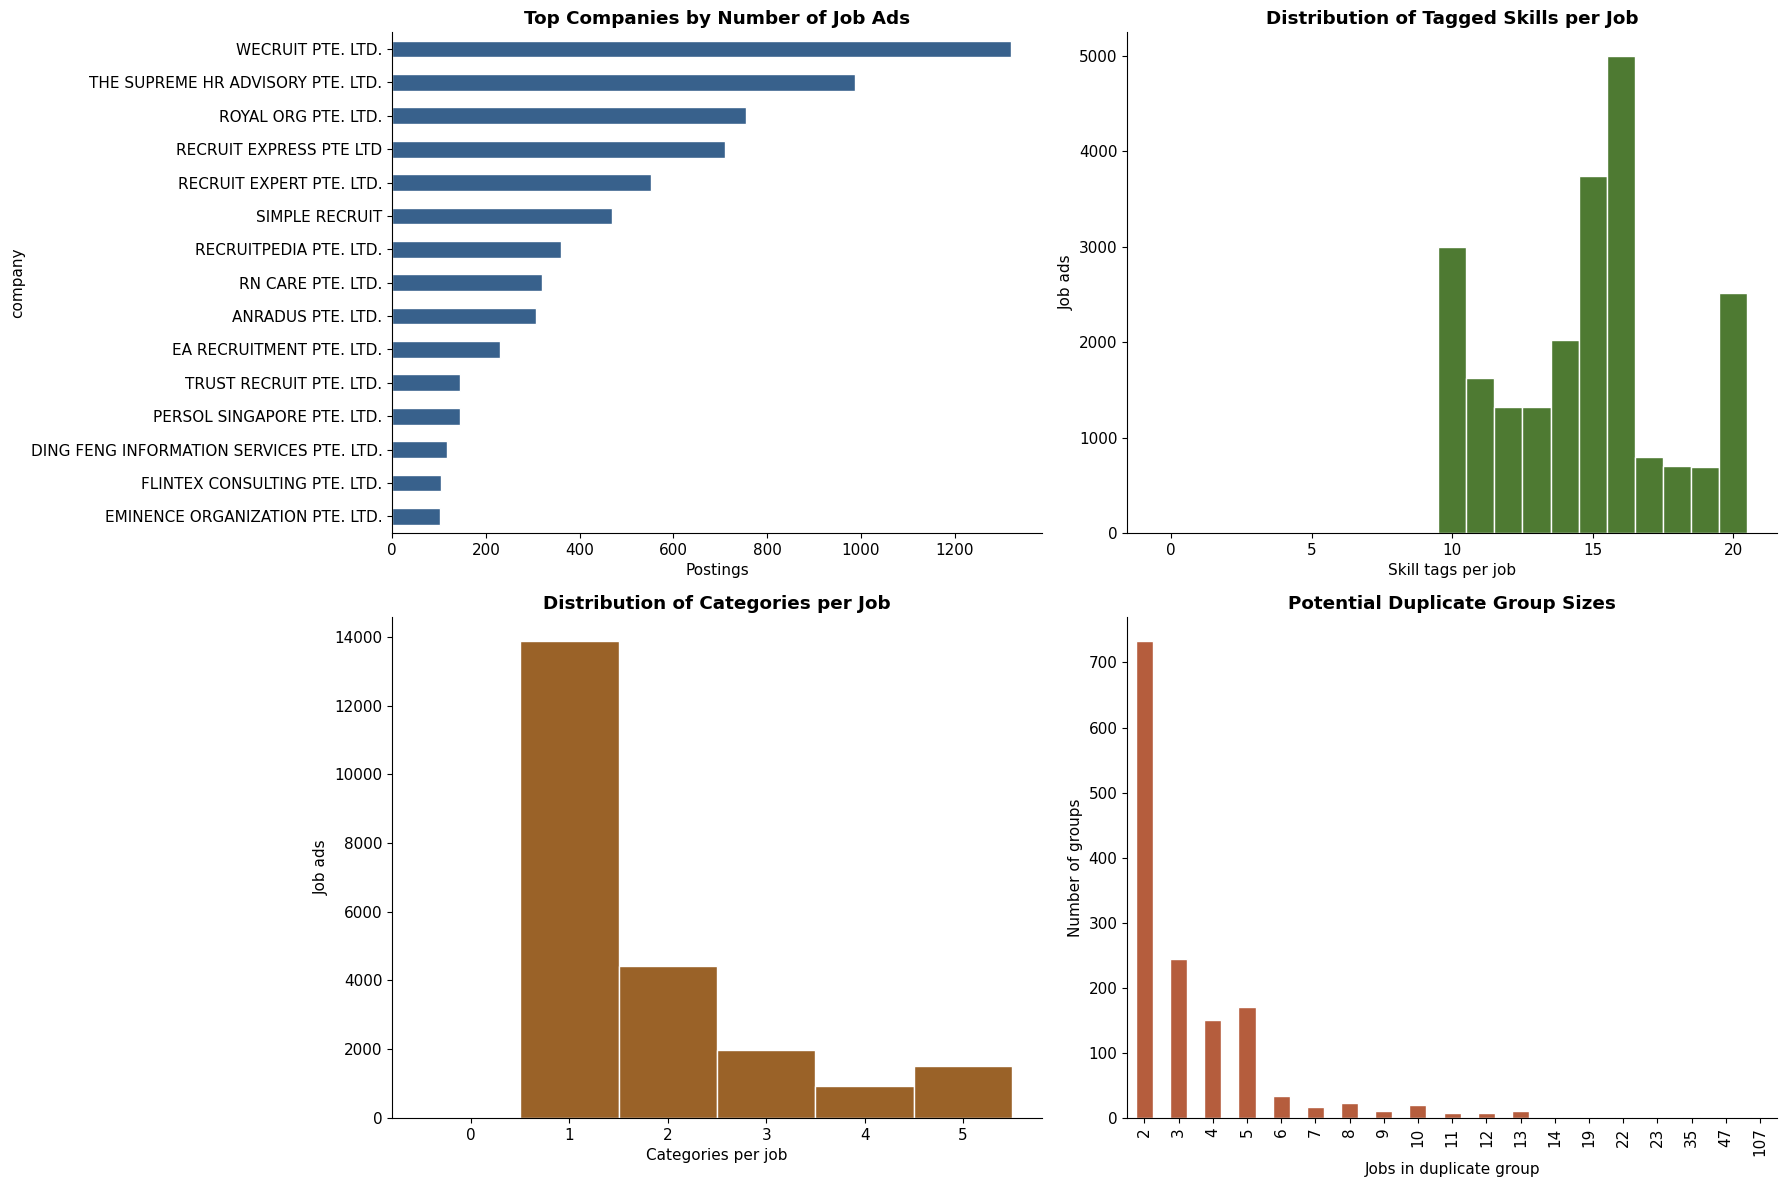

> **Key finding.** Skill tagging is dense rather than sparse: the median job carries 15 skill labels, and the biggest duplicate cluster contains 107 near-identical postings.

In [13]:
top_companies = df["company"].value_counts().head(15).sort_values()
duplicate_group_sizes = duplicate_groups["job_count"].value_counts().sort_index() if not duplicate_groups.empty else pd.Series(dtype="int64")

fig, axes = plt.subplots(2, 2, figsize=(18, 12))

top_companies.plot(kind="barh", ax=axes[0, 0], color="#38618c", edgecolor="white")
axes[0, 0].set_title("Top Companies by Number of Job Ads", fontweight="bold")
axes[0, 0].set_xlabel("Postings")

axes[0, 1].hist(
    df["skill_count"],
    bins=range(0, int(df["skill_count"].max()) + 2),
    color="#4e7a32",
    edgecolor="white",
    align="left",
)
axes[0, 1].set_title("Distribution of Tagged Skills per Job", fontweight="bold")
axes[0, 1].set_xlabel("Skill tags per job")
axes[0, 1].set_ylabel("Job ads")

axes[1, 0].hist(
    df["category_count"],
    bins=range(0, int(df["category_count"].max()) + 2),
    color="#9a6228",
    edgecolor="white",
    align="left",
)
axes[1, 0].set_title("Distribution of Categories per Job", fontweight="bold")
axes[1, 0].set_xlabel("Categories per job")
axes[1, 0].set_ylabel("Job ads")

if duplicate_group_sizes.empty:
    axes[1, 1].text(0.5, 0.5, "No duplicate groups found", ha="center", va="center")
    axes[1, 1].set_title("Potential Duplicate Group Sizes", fontweight="bold")
    axes[1, 1].set_xticks([])
    axes[1, 1].set_yticks([])
else:
    duplicate_group_sizes.plot(kind="bar", ax=axes[1, 1], color="#b55d3d", edgecolor="white")
    axes[1, 1].set_title("Potential Duplicate Group Sizes", fontweight="bold")
    axes[1, 1].set_xlabel("Jobs in duplicate group")
    axes[1, 1].set_ylabel("Number of groups")

for ax in axes.flat:
    ax.spines[["top", "right"]].set_visible(False)
plt.tight_layout()
plt.show()

show_note(
    f"Skill tagging is dense rather than sparse: the median job carries {df['skill_count'].median():.0f} skill labels, and the biggest duplicate cluster contains {duplicate_groups['job_count'].max() if not duplicate_groups.empty else 0} near-identical postings."
)

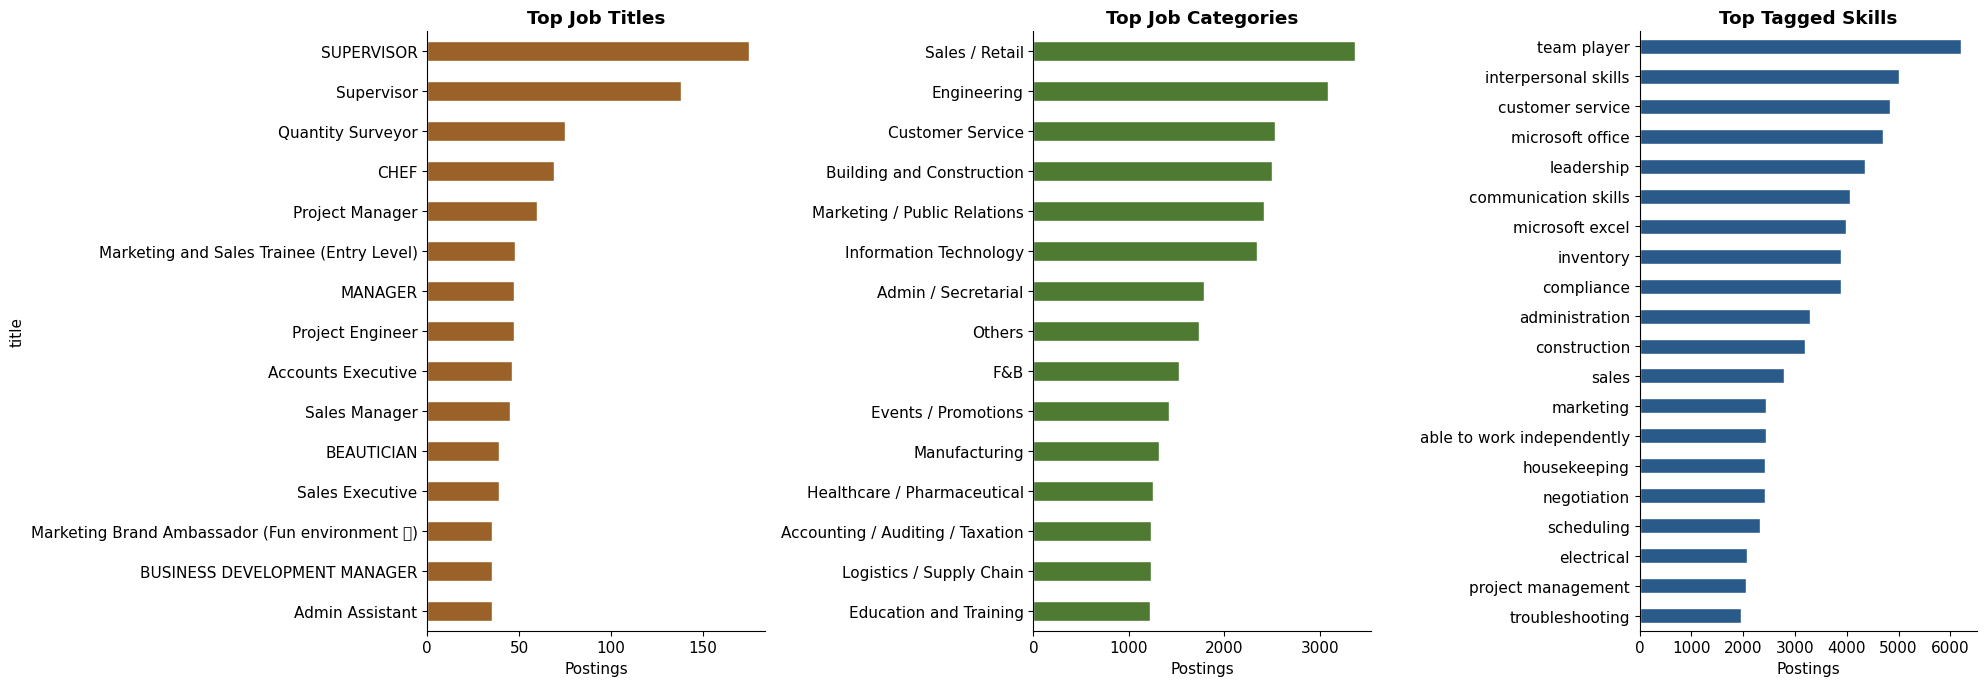

> **Key finding.** The most common category is `Sales / Retail` and the most common tagged skill is `team player`. That points to a job snapshot shaped strongly by broad operational and customer-facing roles, not just specialist technical jobs.

In [14]:
top_titles = df["title"].value_counts().head(15)
cat_counts = all_categories.value_counts().head(15)
top_skills = all_skills.value_counts().head(20)

fig, axes = plt.subplots(1, 3, figsize=(20, 7))
top_titles.sort_values().plot(kind="barh", ax=axes[0], color="#9a6228", edgecolor="white")
axes[0].set_title("Top Job Titles", fontweight="bold")
axes[0].set_xlabel("Postings")

cat_counts.sort_values().plot(kind="barh", ax=axes[1], color="#4e7a32", edgecolor="white")
axes[1].set_title("Top Job Categories", fontweight="bold")
axes[1].set_xlabel("Postings")

top_skills.sort_values().plot(kind="barh", ax=axes[2], color="#2a5a8a", edgecolor="white")
axes[2].set_title("Top Tagged Skills", fontweight="bold")
axes[2].set_xlabel("Postings")

for ax in axes:
    ax.spines[["top", "right"]].set_visible(False)
plt.tight_layout()
plt.show()

show_note(
    f"The most common category is `{cat_counts.idxmax()}` and the most common tagged skill is `{top_skills.idxmax()}`. "
    "That points to a job snapshot shaped strongly by broad operational and customer-facing roles, not just specialist technical jobs."
)